# P01 — Simulador de finanzas conductuales con *ground truth*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantRabbit/p01-behavioral-finance/blob/main/notebooks/P01_Analisis.ipynb)

**Comportamiento en las Finanzas y Toma de Decisiones (ITESO)**  
**Alumnos:** Juan Pablo Sánchez, Matteo Nelson, Edgardo González  
**Profesor:** Prof. Luis Felipe Gómez Estrada  

Este cuaderno recorre los resultados de `outputs/`, generados por

```
python run_simulation.py --agents 1000 --days 504 --assets 60 --bootstrap 1000 --seed 42 --all
```

La pregunta del proyecto no es *¿existe el efecto disposición?* sino
**¿cuándo mienten los estimadores estándar?**. Como los parámetros de
comportamiento se inyectan, se conocen; todo desacuerdo entre lo inyectado y lo
estimado es un resultado, no un defecto.

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

# Compatibilidad con Google Colab: clona el repositorio si se ejecuta en la nube
ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and not (ROOT.parent / "outputs").exists():
    if "google.colab" in sys.modules or not (ROOT / "outputs").exists():
        print("Entorno Google Colab detectado. Clonando repositorio para acceder a outputs...")
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/QuantRabbit/p01-behavioral-finance.git"], check=False)
        if (ROOT / "p01-behavioral-finance" / "outputs").exists():
            os.chdir("p01-behavioral-finance")
            ROOT = Path.cwd()

if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
OUT = ROOT / "outputs"
FIG = OUT / "figuras"

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

resultados = json.loads((OUT / "resultados_completos.json").read_text(encoding="utf-8"))
tabla = pd.read_csv(OUT / "tabla_principal.csv")
diag = pd.read_csv(OUT / "tabla_diagnosticos.csv")
barrido = pd.read_csv(OUT / "barrido_monotonicidad.csv")
nulos = pd.read_csv(OUT / "replicas_nulo.csv")
disp_reps = pd.read_csv(OUT / "replicas_disposicion_alta.csv")
rejilla = pd.read_csv(OUT / "sensibilidad_contable.csv")
rejilla_ancha = pd.read_csv(OUT / "sensibilidad_contable_spread_ancho.csv")
firmas = pd.read_csv(OUT / "matriz_firmas.csv").set_index("escenario")
clasif = pd.read_csv(OUT / "clasificacion_firmas.csv")

meta = resultados["meta"]
print(f"Semilla maestra: {meta['semilla_maestra']}   Python {meta['python']}   numpy {meta['numpy']}")
print(f"Tiempo total de computo: {meta['tiempo_total_s']:.1f} s")
print(f"Escenarios en la tabla principal: {len(tabla)}")


Semilla maestra: 42   Python 3.13.1   numpy 2.2.2
Tiempo total de computo: 383.9 s
Escenarios en la tabla principal: 9


## 1. El mercado

Tres factores comunes (mercado, sector, estilo) más ruido idiosincrático, todos
i.i.d. en el tiempo. **No hay momentum ni reversión real**: cualquier patrón
temporal que un agente crea ver es una creencia falsa. Eso es lo que convierte
al escenario 8 en un *confound* genuino y no en una estrategia que funciona.

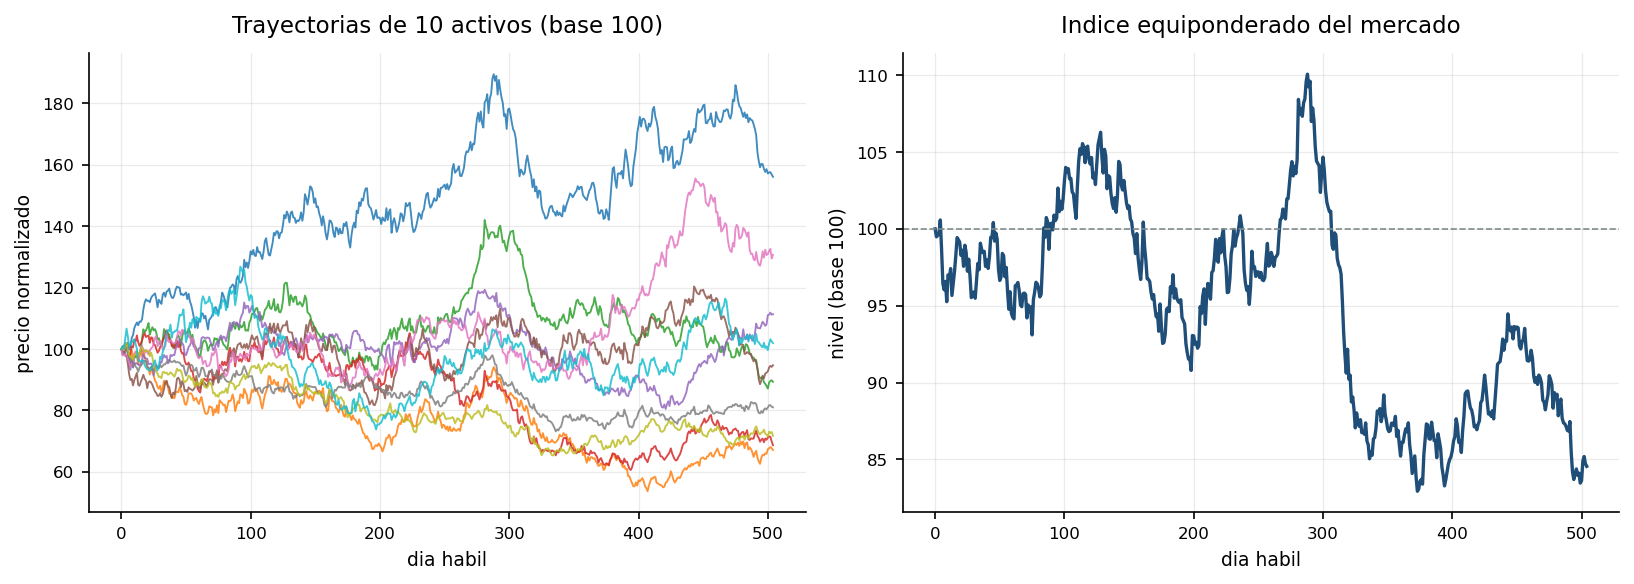

In [2]:
display(Image(str(FIG / "fig01_trayectorias_precios.png")))

In [3]:
from src.config import MarketConfig, derive_rngs
from src.price_process import generate_market, pooled_autocorrelation

mk = generate_market(MarketConfig(), derive_rngs("esc1_nulo", 42)["prices"])
acf = [pooled_autocorrelation(mk.log_returns, k) for k in range(1, 11)]
print("Autocorrelacion agrupada, rezagos 1..10:")
print(np.round(acf, 5))
print(f"\nmaximo |acf| = {max(abs(a) for a in acf):.5f}")
corr = np.corrcoef(mk.log_returns.T)
print(f"correlacion transversal media entre activos = {corr[~np.eye(60, dtype=bool)].mean():.3f}")

Autocorrelacion agrupada, rezagos 1..10:
[-0.01085 -0.0019  -0.01033 -0.02205  0.01128  0.00541  0.02053  0.0022
  0.00043 -0.00776]

maximo |acf| = 0.02205
correlacion transversal media entre activos = 0.354


## 2. Los parámetros inyectados son distribuciones, no escalares

Si todos los agentes compartieran el mismo `delta`, la correlación con `kappa`
saldría exactamente cero **por varianza cero**, no por independencia, y la
regresión de Barber-Odean se quedaría sin variación transversal. En cada
escenario con objetivo distinto de cero, `delta` y `kappa` se sortean de una
Beta reparametrizada por media y concentración.

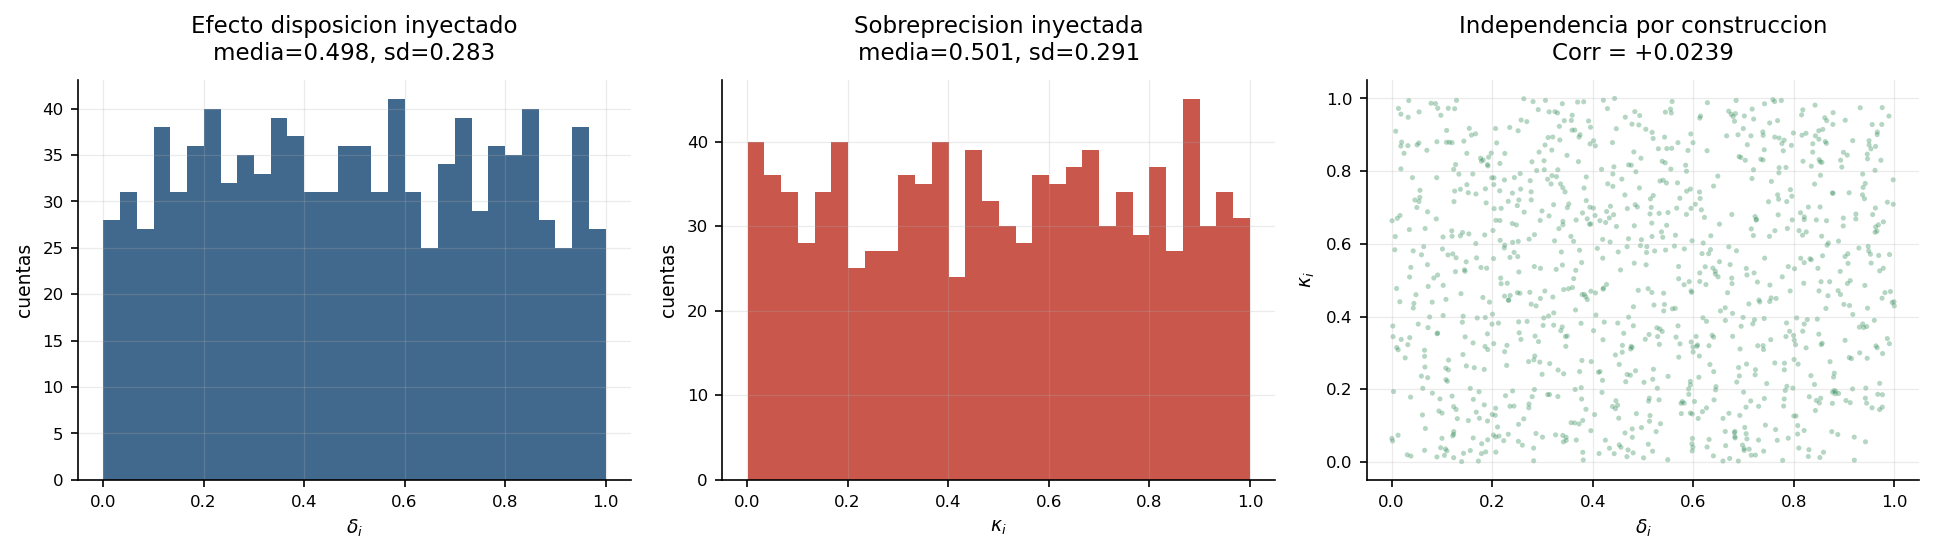

In [4]:
display(Image(str(FIG / "fig02_distribucion_delta_kappa.png")))

In [5]:
print(tabla[["#", "escenario", "delta_iny_media", "delta_iny_sd",
             "kappa_iny_media", "kappa_iny_sd"]].round(4).to_string(index=False))

 #             escenario  delta_iny_media  delta_iny_sd  kappa_iny_media  kappa_iny_sd
 1                  Nulo           0.0000        0.0000           0.0000        0.0000
 2      Disposicion baja           0.3050        0.1050           0.0000        0.0000
 3      Disposicion alta           0.7997        0.0852           0.0000        0.0000
 4         Rotacion baja           0.0000        0.0000           0.3015        0.1007
 5         Rotacion alta           0.0000        0.0000           0.7988        0.0852
 6         Ambos activos           0.7986        0.0900           0.8020        0.0867
 7   Confound rebalanceo           0.0000        0.0000           0.0000        0.0000
 8    Confound reversion           0.0000        0.0000           0.0000        0.0000
 9 Poblacion heterogenea           0.4981        0.2832           0.5008        0.2906


## 3. Tabla principal

Nueve filas: los ocho escenarios canónicos más la población heterogénea
completa.

In [6]:
cols = ["#", "escenario", "PGR", "PLR", "PGR_menos_PLR", "SE_boot", "z", "PGR_sobre_PLR"]
print(tabla[cols].round(5).to_string(index=False))

 #             escenario     PGR     PLR  PGR_menos_PLR  SE_boot         z  PGR_sobre_PLR
 1                  Nulo 0.05752 0.05732        0.00021  0.00031   0.66751        1.00358
 2      Disposicion baja 0.07003 0.04065        0.02938  0.00053  55.39351        1.72278
 3      Disposicion alta 0.11924 0.02212        0.09712  0.00106  91.49468        5.39019
 4         Rotacion baja 0.06828 0.06882       -0.00054  0.00026  -2.08837        0.99216
 5         Rotacion alta 0.08918 0.08919       -0.00001  0.00023  -0.05761        0.99985
 6         Ambos activos 0.17656 0.02751        0.14905  0.00119 125.26363        6.41762
 7   Confound rebalanceo 0.05070 0.03835        0.01235  0.00070  17.51548        1.32198
 8    Confound reversion 0.08828 0.04737        0.04091  0.00045  90.45625        1.86358
 9 Poblacion heterogenea 0.11929 0.04609        0.07320  0.00186  39.33282        2.58823


In [7]:
cols = ["#", "escenario", "delta_iny_media", "delta_hat", "SE_delta_hat",
        "error_recuperacion", "delta_hat_por_agente"]
print(tabla[cols].round(5).to_string(index=False))
print(f"\nError absoluto maximo de recuperacion en escenarios sin confound: "
      f"{tabla.loc[~tabla['#'].isin([7, 8]), 'error_recuperacion'].abs().max():.5f}")

 #             escenario  delta_iny_media  delta_hat  SE_delta_hat  error_recuperacion  delta_hat_por_agente
 1                  Nulo          0.00000    0.00197       0.00287             0.00197               0.00025
 2      Disposicion baja          0.30497    0.30315       0.00442            -0.00182               0.30288
 3      Disposicion alta          0.79969    0.79935       0.00334            -0.00034               0.79540
 4         Rotacion baja          0.00000   -0.00631       0.00196            -0.00631              -0.00039
 5         Rotacion alta          0.00000   -0.00030       0.00132            -0.00030              -0.00052
 6         Ambos activos          0.79861    0.80146       0.00310             0.00285               0.79831
 7   Confound rebalanceo          0.00000    0.16202       0.00833             0.16202               0.20392
 8    Confound reversion          0.00000    0.37641       0.00192             0.37641               0.37627
 9 Poblacion hetero

### El hallazgo central

`PGR - PLR` **no** es una estimación de `delta`. El estimador estructural por
razón de hazards sí lo es. En la figura los escenarios sin *confound* caen sobre
la diagonal de 45 grados; los dos *confounds*, con `delta = 0` inyectado, quedan
muy por encima del cero.

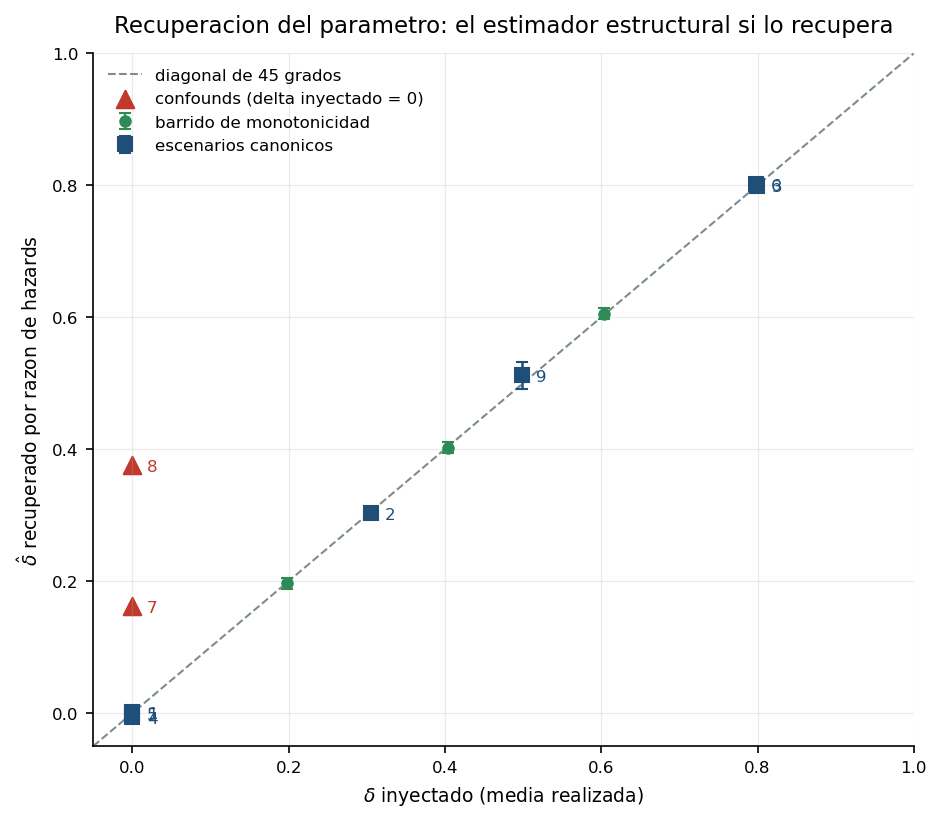

In [8]:
display(Image(str(FIG / "fig04_delta_recuperado_vs_inyectado.png")))

In [9]:
# Mismo delta, distinto kappa: PGR - PLR cambia, delta_hat no.
comp = tabla[tabla["#"].isin([3, 6])][
    ["#", "escenario", "delta_iny_media", "kappa_iny_media",
     "PGR_menos_PLR", "PGR_sobre_PLR", "delta_hat", "turnover_medio"]
]
print(comp.round(4).to_string(index=False))
f3, f6 = comp.iloc[0], comp.iloc[1]
print(f"\nMismo delta inyectado ({f3.delta_iny_media:.3f} vs {f6.delta_iny_media:.3f}) "
      f"pero PGR-PLR cambia un {100 * (f6.PGR_menos_PLR / f3.PGR_menos_PLR - 1):+.0f}%, "
      f"mientras que delta_hat cambia un {100 * (f6.delta_hat / f3.delta_hat - 1):+.2f}%.")

 #        escenario  delta_iny_media  kappa_iny_media  PGR_menos_PLR  PGR_sobre_PLR  delta_hat  turnover_medio
 3 Disposicion alta           0.7997            0.000         0.0971         5.3902     0.7994          1.9765
 6    Ambos activos           0.7986            0.802         0.1490         6.4176     0.8015          6.8650

Mismo delta inyectado (0.800 vs 0.799) pero PGR-PLR cambia un +53%, mientras que delta_hat cambia un +0.26%.


## 4. Monotonicidad

`PGR - PLR` es monótona creciente en `delta` pero vive en otra escala; `delta_hat`
sigue la diagonal. En el barrido de `kappa` el estimador de disposición se queda
callado, que es la prueba de silencio cruzado.

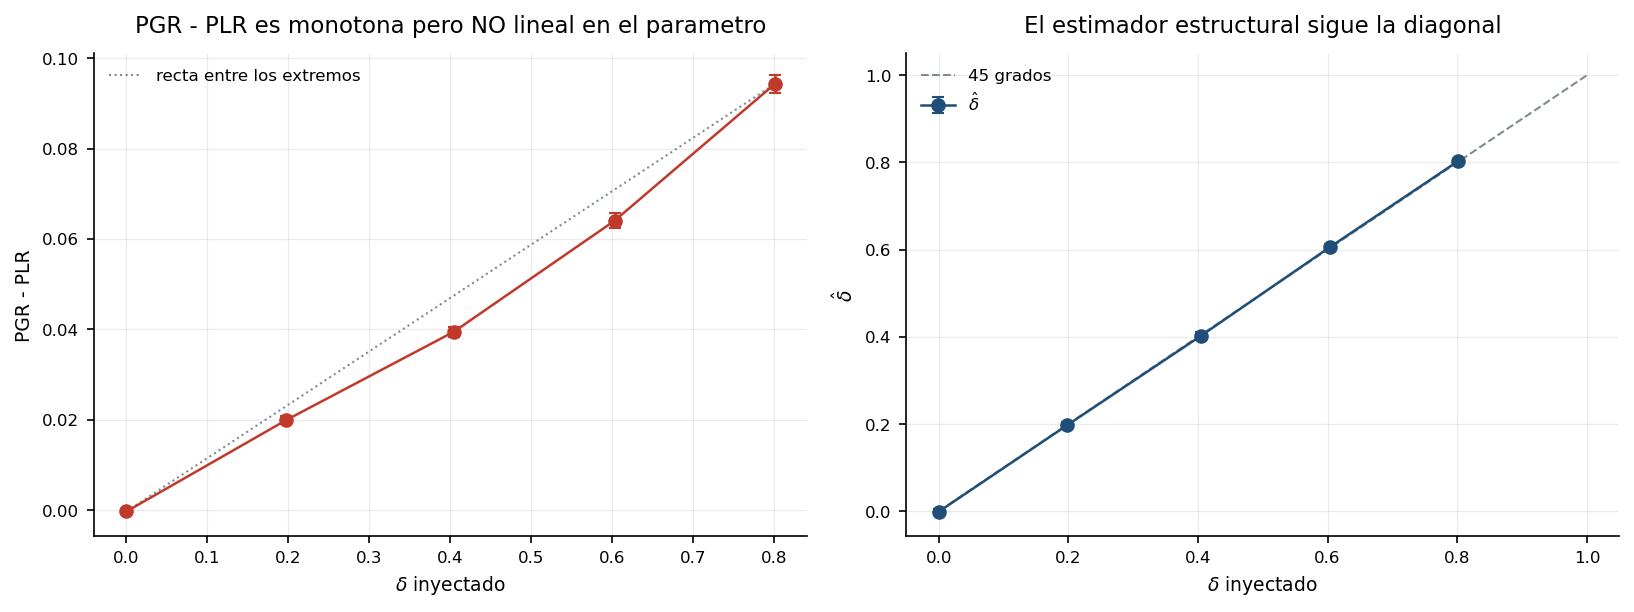

In [10]:
display(Image(str(FIG / "fig05_pgr_menos_plr_vs_delta.png")))

In [11]:
print(barrido[["parametro", "valor_inyectado", "media_realizada", "PGR_menos_PLR",
               "PGR_sobre_PLR", "delta_hat", "beta_net", "p_beta_net",
               "turnover_medio"]].round(5).to_string(index=False))

parametro  valor_inyectado  media_realizada  PGR_menos_PLR  PGR_sobre_PLR  delta_hat  beta_net  p_beta_net  turnover_medio
    delta              0.0          0.00000       -0.00027        0.99514   -0.00118  -0.00343     0.75397         3.04900
    delta              0.2          0.19754        0.01996        1.40837    0.19667   0.05055     0.00001         3.02398
    delta              0.4          0.40437        0.03948        2.11468    0.40209   0.06620     0.00000         3.08402
    delta              0.6          0.60294        0.06405        3.10613    0.60524   0.06685     0.00000         2.62922
    delta              0.8          0.80065        0.09428        6.83251    0.80253   0.10917     0.00000         2.47510
    kappa              0.0          0.00000       -0.00038        0.99344   -0.00121   0.00327     0.80509         3.12262
    kappa              0.2          0.20311       -0.00001        0.99978   -0.00129  -0.00298     0.34726         5.16971
    kappa       

In [12]:
d = barrido[barrido.parametro == "delta"]
teorico = (1 + d.media_realizada) / (1 - d.media_realizada)
cmp_ratio = pd.DataFrame({
    "delta": d.media_realizada.round(3),
    "PGR/PLR observado": d.PGR_sobre_PLR.round(3),
    "HR teorico (1+d)/(1-d)": teorico.round(3),
    "subestimacion %": (100 * (d.PGR_sobre_PLR / teorico - 1)).round(1),
})
print(cmp_ratio.to_string(index=False))
print("\nLa RAZON PGR/PLR va en la direccion correcta pero subestima la razon de")
print("hazards, y la subestimacion crece con delta: condicionar en dias con venta")
print("no es lo mismo que medir la tasa de riesgo.")

 delta  PGR/PLR observado  HR teorico (1+d)/(1-d)  subestimacion %
 0.000              0.995                   1.000             -0.5
 0.198              1.408                   1.492             -5.6
 0.404              2.115                   2.358            -10.3
 0.603              3.106                   4.037            -23.1
 0.801              6.833                   9.033            -24.4

La RAZON PGR/PLR va en la direccion correcta pero subestima la razon de
hazards, y la subestimacion crece con delta: condicionar en dias con venta
no es lo mismo que medir la tasa de riesgo.


## 5. Validación bajo el nulo, y por qué hay que desconfiar de los estadísticos z

Veinte réplicas del escenario nulo con semillas distintas: cada réplica es una
economía independiente (trayectoria de precios nueva y población nueva).

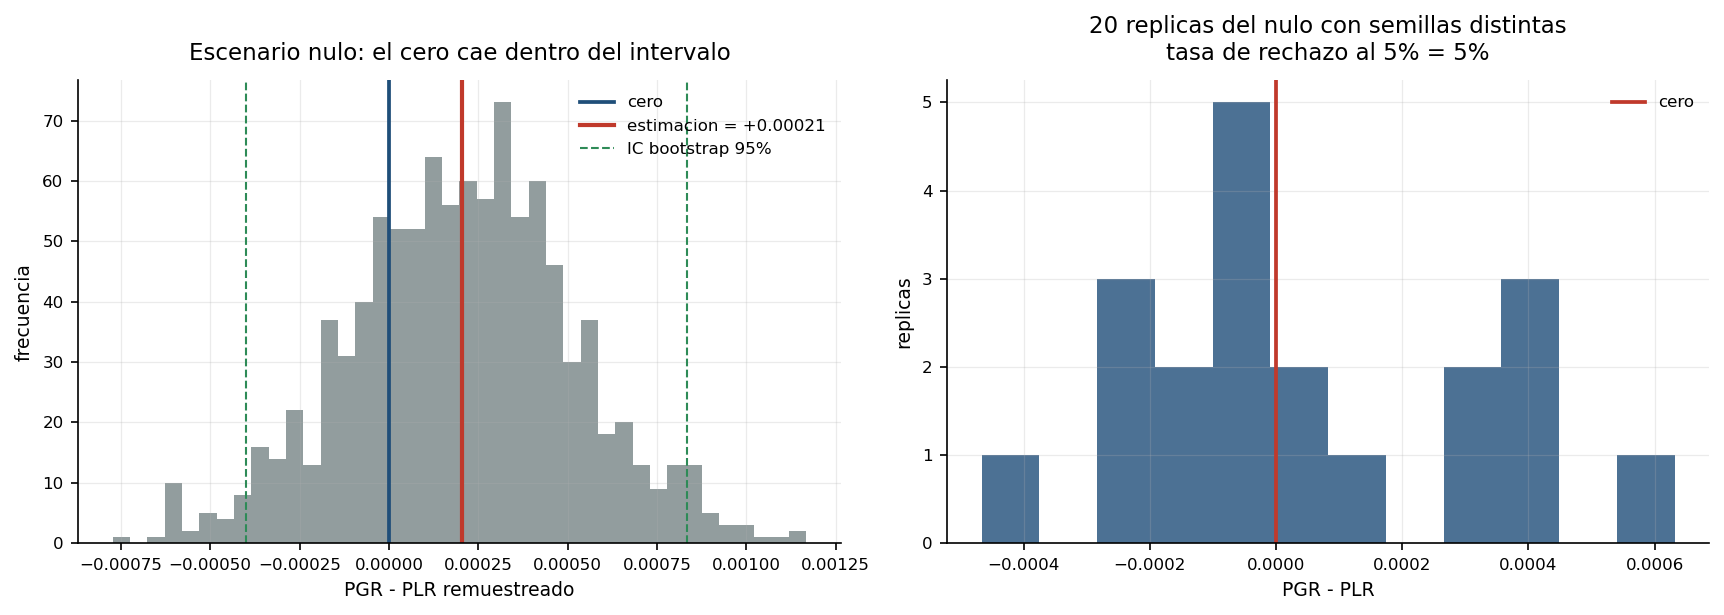

In [13]:
display(Image(str(FIG / "fig09_bootstrap_nulo.png")))

In [14]:
print(f"Replicas: {len(nulos)}")
print(f"Rechazos al 5% de PGR-PLR : {int(nulos.rechaza_5pct.sum())}/{len(nulos)} "
      f"({nulos.rechaza_5pct.mean():.0%})")
print(f"Rechazos al 5% de delta_hat: {int(nulos.rechaza_delta_5pct.sum())}/{len(nulos)}")
print(f"Rechazos al 5% de beta_net : {int(nulos.rechaza_beta_net_5pct.sum())}/{len(nulos)}")
print(f"Cero dentro del IC al 95%  : {int(nulos.cero_dentro_ci.sum())}/{len(nulos)}")

Replicas: 20
Rechazos al 5% de PGR-PLR : 1/20 (5%)
Rechazos al 5% de delta_hat: 1/20
Rechazos al 5% de beta_net : 0/20
Cero dentro del IC al 95%  : 19/20


In [15]:
res = resultados["resumen_replicas"]
filas = []
for k, v in res.items():
    filas.append({
        "cantidad": k,
        "sd entre trayectorias": v["sd_entre_trayectorias"],
        "SE bootstrap medio": v["se_bootstrap_medio"],
        "factor": v["factor_sd_sobre_se"],
        "replicas": v["n_replicas"],
    })
print(pd.DataFrame(filas).round(6).to_string(index=False))
print('''
Lectura: bajo el nulo el bootstrap por cuenta esta bien calibrado (factor ~1).
Pero en el escenario de disposicion alta la dispersion de PGR-PLR ENTRE
trayectorias es 16.6 veces su error estandar bootstrap. El bootstrap agrupado
por cuenta esta condicionado a UNA sola realizacion del mercado y no puede ver
esa fuente de variabilidad. El z = 91 que reporta la tabla principal es un
z condicional; el z incondicional relevante es del orden de 5.5.
delta_hat, en cambio, tiene factor 1.12: sus z si son honestos.''')

          cantidad  sd entre trayectorias  SE bootstrap medio    factor  replicas
nulo_PGR_menos_PLR               0.000279            0.000306  0.911409        20
    nulo_delta_hat               0.002832            0.002778  1.019249        20
disp_PGR_menos_PLR               0.016444            0.000988 16.643216        10
    disp_delta_hat               0.003702            0.003293  1.124440        10

Lectura: bajo el nulo el bootstrap por cuenta esta bien calibrado (factor ~1).
Pero en el escenario de disposicion alta la dispersion de PGR-PLR ENTRE
trayectorias es 16.6 veces su error estandar bootstrap. El bootstrap agrupado
por cuenta esta condicionado a UNA sola realizacion del mercado y no puede ver
esa fuente de variabilidad. El z = 91 que reporta la tabla principal es un
z condicional; el z incondicional relevante es del orden de 5.5.
delta_hat, en cambio, tiene factor 1.12: sus z si son honestos.


In [16]:
boot = resultados["bootstrap_comparacion"]
print("Escenario 3, PGR - PLR:")
print(f"  SE bootstrap agrupado por cuenta : {boot['se_agrupado_por_cuenta']:.6f}  (z = {boot['z_agrupado']:.1f})")
print(f"  SE bootstrap por transaccion     : {boot['se_por_transaccion']:.6f}  (z = {boot['z_por_transaccion']:.1f})")
print(f"  Factor de subestimacion por ignorar el agrupamiento: {boot['factor_subestimacion']:.2f}x")
print(f"\n  Y si ademas se ignora la trayectoria de precios, el factor acumulado es "
      f"{boot['factor_subestimacion'] * res['disp_PGR_menos_PLR']['factor_sd_sobre_se']:.0f}x.")

Escenario 3, PGR - PLR:
  SE bootstrap agrupado por cuenta : 0.001063  (z = 91.4)
  SE bootstrap por transaccion     : 0.000502  (z = 193.3)
  Factor de subestimacion por ignorar el agrupamiento: 2.12x

  Y si ademas se ignora la trayectoria de precios, el factor acumulado es 35x.


## 6. El estadístico de horizontes de tenencia está arrastrado por la deriva

Odean (1998) documenta que los inversionistas retienen las perdedoras más tiempo
que las ganadoras. Bajo el nulo (`delta = kappa = 0`) esa brecha **no** debería
existir. Sobre veinte trayectorias independientes, su signo lo decide el retorno
realizado del mercado.

In [17]:
der = resultados["deriva_y_brecha_de_tenencia"]
print(nulos[["replica", "retorno_mercado_ew", "tenencia_ganadoras",
             "tenencia_perdedoras", "brecha_tenencia"]].round(3).to_string(index=False))
print(f"\nCorr(retorno del mercado, brecha de tenencia) = {der['corr_retorno_mercado_brecha_tenencia']:+.3f} "
      f"(t = {der['t']:.2f}, n = {der['n_replicas']})")
neg = int((nulos.brecha_tenencia < 0).sum())
print(f"Replicas con brecha negativa, es decir con la lectura clasica de "
      f"'retiene perdedoras': {neg}/{len(nulos)}  -- y en todas ellas delta = 0.")

 replica  retorno_mercado_ew  tenencia_ganadoras  tenencia_perdedoras  brecha_tenencia
       0              -0.021              59.157               69.000           -9.843
       1               0.067              70.218               58.000           12.218
       2              -0.094              65.540               62.938            2.601
       3               0.306              72.289               50.016           22.273
       4               0.199              70.972               54.500           16.472
       5               0.857              72.998               43.000           29.998
       6               0.449              76.190               44.815           31.376
       7              -0.256              55.000               68.380          -13.380
       8               0.195              77.385               49.000           28.385
       9               0.186              65.503               62.000            3.503
      10               0.419              6

## 7. Barber-Odean, causalidad reversa e IV

In [18]:
cols = ["#", "escenario", "beta_gross", "p_beta_gross", "beta_net", "p_beta_net",
        "beta_iv_net", "F_primera_etapa"]
print(tabla[cols].round(5).to_string(index=False))
print("\nNaN en las columnas de IV = kappa es degenerado en ese escenario, por lo que")
print("el modelo NO esta identificado. No se reporta un numero inventado.")

 #             escenario  beta_gross  p_beta_gross  beta_net  p_beta_net  beta_iv_net  F_primera_etapa
 1                  Nulo     0.00814       0.37406   0.00527     0.56354          NaN              NaN
 2      Disposicion baja     0.04868       0.00000   0.04535     0.00000          NaN              NaN
 3      Disposicion alta     0.06170       0.00000   0.05895     0.00000          NaN              NaN
 4         Rotacion baja     0.00127       0.70667  -0.00275     0.41996     -0.00434       3662.65988
 5         Rotacion alta    -0.00242       0.40975  -0.00586     0.04423     -0.00632       1533.95801
 6         Ambos activos     0.00656       0.00360   0.00279     0.21296     -0.01198        175.26345
 7   Confound rebalanceo     0.26723       0.00751   0.25345     0.01126          NaN              NaN
 8    Confound reversion     0.06178       0.00000   0.05958     0.00000          NaN              NaN
 9 Poblacion heterogenea     0.00136       0.17147  -0.00263     0.00883 

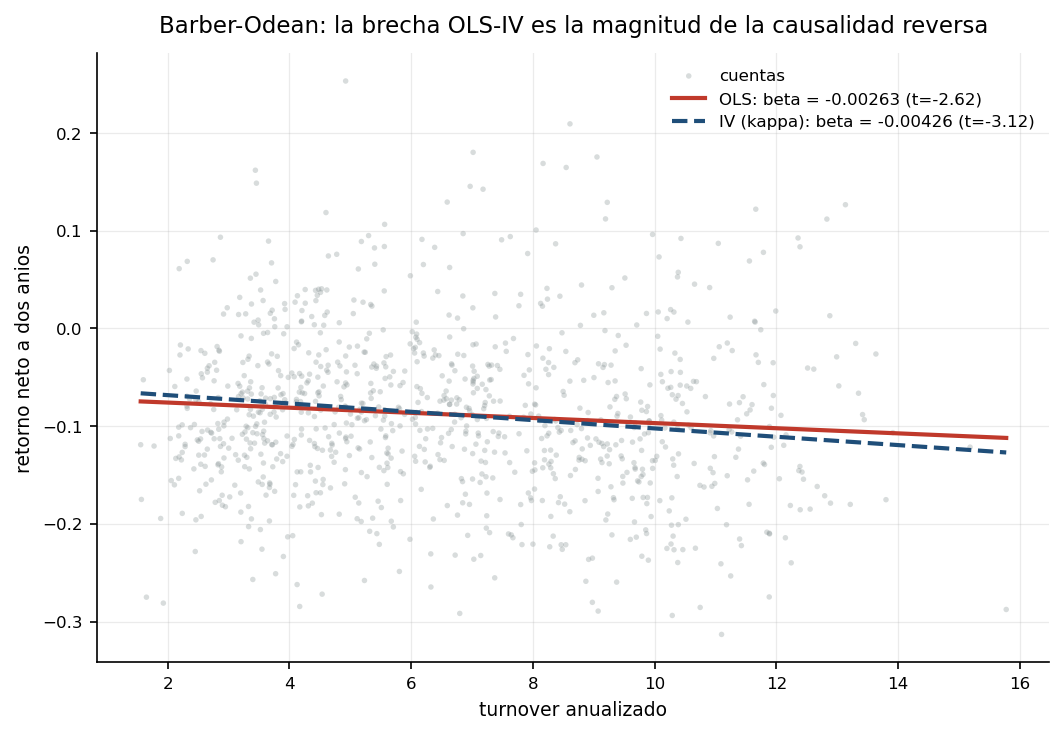

In [19]:
display(Image(str(FIG / "fig06_turnover_vs_retorno.png")))

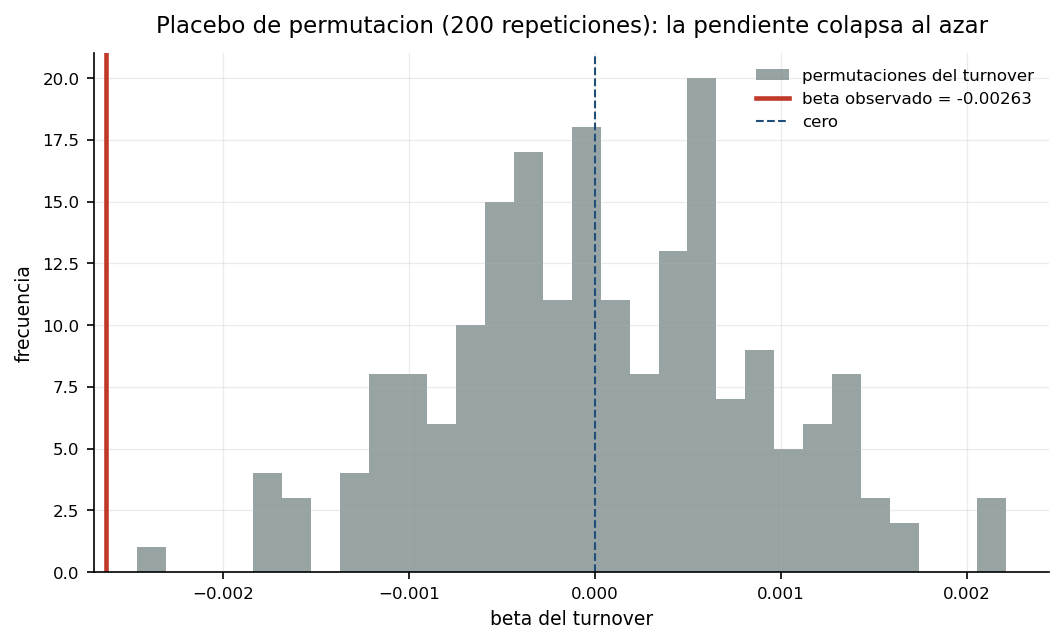

In [20]:
display(Image(str(FIG / "fig07_placebo_permutacion.png")))

In [21]:
cols = ["#", "escenario", "beta_hacia_atras", "t_hacia_atras",
        "beta_ols_net", "beta_iv_net", "brecha_net"]
print(diag[cols].round(5).to_string(index=False))
print('''
La regresion 'hacia atras' regresa el turnover contra el retorno bruto. Si el
turnover causara el retorno y no al reves, no deberia encontrar nada. En los
escenarios con delta > 0 sale fuertemente positiva: la cuenta que tuvo suerte
acumula ganadoras, las vende (porque la regla condiciona en el precio de compra)
y registra mas turnover.''')

 #             escenario  beta_hacia_atras  t_hacia_atras  beta_ols_net  beta_iv_net  brecha_net
 1                  Nulo           0.14296        0.89452       0.00527          NaN         NaN
 2      Disposicion baja           0.73115        5.12035       0.04535          NaN         NaN
 3      Disposicion alta           2.06059       10.77907       0.05895          NaN         NaN
 4         Rotacion baja           0.09585        0.37644      -0.00275     -0.00434     0.00159
 5         Rotacion alta          -0.31534       -0.82309      -0.00586     -0.00632     0.00046
 6         Ambos activos           1.47029        2.99525       0.00279     -0.01198     0.01477
 7   Confound rebalanceo           0.02626        2.66324       0.25345          NaN         NaN
 8    Confound reversion           1.38278        8.44838       0.05958          NaN         NaN
 9 Poblacion heterogenea           1.24397        1.38253      -0.00263     -0.00426     0.00163

La regresion 'hacia atras' re

### Diagnóstico de la pendiente bruta positiva

El enunciado enumera cinco causas posibles: fuga de información, *cash drag*,
contaminación por spread, efectos de composición y causalidad reversa. Se
discriminan una por una con las cuentas exportadas.

In [22]:
cuentas = {k: pd.read_csv(OUT / f"cuentas_{k}.csv")
           for k in ["esc1_nulo", "esc3_disposicion_alta", "esc7_confound_rebalanceo",
                     "esc8_confound_reversion", "esc9_heterogeneo"]}

filas = []
for k, a in cuentas.items():
    filas.append({
        "escenario": k.replace("esc", "").replace("_", " "),
        "corr(turnover, r_gross)": np.corrcoef(a.turnover, a.gross_return)[0, 1],
        "corr(turnover, vol)": np.corrcoef(a.turnover, a.portfolio_vol)[0, 1],
        "corr(turnover, hhi)": np.corrcoef(a.turnover, a.hhi)[0, 1],
        "corr(turnover, capacidad)": np.corrcoef(a.turnover, a.capacity)[0, 1],
        "corr(turnover, efectivo)": np.corrcoef(a.turnover, a.mean_cash_weight)[0, 1],
    })
print(pd.DataFrame(filas).round(3).to_string(index=False))

            escenario  corr(turnover, r_gross)  corr(turnover, vol)  corr(turnover, hhi)  corr(turnover, capacidad)  corr(turnover, efectivo)
               1 nulo                    0.039                0.048                0.067                     -0.043                     0.061
   3 disposicion alta                    0.367                0.001               -0.012                      0.066                     0.245
7 confound rebalanceo                   -0.004               -0.444               -0.685                      0.748                     0.361
 8 confound reversion                    0.298               -0.051               -0.056                      0.064                     0.080
        9 heterogeneo                    0.063               -0.069                0.031                      0.013                     0.470


In [23]:
from src.estimators import barber_odean_regression

a7 = cuentas["esc7_confound_rebalanceo"]
r7 = barber_odean_regression(a7, "gross_return")
print("Escenario 7 (rebalanceo), regresion bruta completa:")
for n, b, t in zip(r7["names"], r7["beta"], r7["t"]):
    print(f"   {n:<18} beta = {b:+10.5f}   t = {t:+7.2f}")
print(f"\nR2 = {r7['r2']:.3f}")

r7b = barber_odean_regression(a7, "gross_return", controls=["log_wealth", "capacity"])
print(f"\nMisma regresion sin los controles de volatilidad, efectivo y HHI: "
      f"beta_turnover = {r7b['beta_turnover']:+.5f} (t = {r7b['t_turnover']:.2f})")
print(f"Correlacion simple turnover-retorno bruto: "
      f"{np.corrcoef(a7.turnover, a7.gross_return)[0, 1]:+.4f}")
print('''
Diagnostico: en el escenario 7 la relacion CRUDA entre turnover y retorno bruto
es practicamente nula. La pendiente positiva aparece SOLO al condicionar en la
volatilidad de la cartera, que en esta trayectoria explica casi todo el retorno
(t = 16) y esta negativamente correlacionada con el turnover. Es un efecto de
composicion inducido por los controles, no causalidad reversa ni fuga.''')

Escenario 7 (rebalanceo), regresion bruta completa:
   const              beta =   -0.91343   t =   -6.17
   turnover           beta =   +0.26723   t =   +2.67
   log_wealth         beta =   +0.00346   t =   +0.98
   capacity           beta =   -0.00248   t =   -1.68
   portfolio_vol      beta =  +10.54427   t =  +16.43
   mean_cash_weight   beta =   -2.31089   t =   -1.21
   hhi                beta =   -1.34402   t =   -4.87

R2 = 0.312

Misma regresion sin los controles de volatilidad, efectivo y HHI: beta_turnover = -0.06925 (t = -0.86)
Correlacion simple turnover-retorno bruto: -0.0038

Diagnostico: en el escenario 7 la relacion CRUDA entre turnover y retorno bruto
es practicamente nula. La pendiente positiva aparece SOLO al condicionar en la
volatilidad de la cartera, que en esta trayectoria explica casi todo el retorno
(t = 16) y esta negativamente correlacionada con el turnover. Es un efecto de
composicion inducido por los controles, no causalidad reversa ni fuga.


In [24]:
a3 = cuentas["esc3_disposicion_alta"]
print("Escenario 3 (disposicion alta):")
print(f"  correlacion simple turnover-retorno bruto = {np.corrcoef(a3.turnover, a3.gross_return)[0, 1]:+.4f}")
print(f"  regresion hacia atras: beta = {diag.loc[diag['#'] == 3, 'beta_hacia_atras'].iloc[0]:.3f}, "
      f"t = {diag.loc[diag['#'] == 3, 't_hacia_atras'].iloc[0]:.2f}")
print(f"  IV: {'identificado' if np.isfinite(tabla.loc[tabla['#'] == 3, 'beta_iv_net'].iloc[0]) else 'NO identificado (kappa degenerado)'}")
print('''
Aqui la relacion cruda si existe y es fuerte: es causalidad reversa genuina.
Y no se puede corregir, porque en una poblacion donde todos comparten el mismo
kappa no existe variacion exogena que sirva de instrumento. El econometrista se
queda sin herramienta justo cuando mas la necesita.''')

Escenario 3 (disposicion alta):
  correlacion simple turnover-retorno bruto = +0.3665
  regresion hacia atras: beta = 2.061, t = 10.78
  IV: NO identificado (kappa degenerado)

Aqui la relacion cruda si existe y es fuerte: es causalidad reversa genuina.
Y no se puede corregir, porque en una poblacion donde todos comparten el mismo
kappa no existe variacion exogena que sirva de instrumento. El econometrista se
queda sin herramienta justo cuando mas la necesita.


In [25]:
filas = []
for _, r in diag.iterrows():
    filas.append({
        "#": int(r["#"]), "escenario": r["escenario"],
        "pendiente spread observada": r["spread_pendiente_obs"],
        "pendiente spread teorica": r["spread_pendiente_teorica"],
        "error relativo": r["spread_error_rel"],
        "peso de comisiones": r["peso_comisiones"],
        "desplazamiento por cash drag": r["cash_drag_desplazamiento"],
    })
print(pd.DataFrame(filas).round(5).to_string(index=False))
print("\nLa contaminacion por spread queda descartada por construccion: los dos libros")
print("contables paralelos hacen que r_gross - r_net sea exactamente el costo pagado,")
print("y la pendiente observada coincide con la teorica dentro de un 12%.")

 #             escenario  pendiente spread observada  pendiente spread teorica  error relativo  peso de comisiones  desplazamiento por cash drag
 1                  Nulo                     0.00189                   0.00189         0.00103             0.52497                      -0.00026
 2      Disposicion baja                     0.00236                   0.00221         0.06778             0.50942                       0.00013
 3      Disposicion alta                     0.00197                   0.00180         0.09191             0.53289                      -0.00069
 4         Rotacion baja                     0.00235                   0.00240         0.02235             0.48157                      -0.00258
 5         Rotacion alta                     0.00197                   0.00205         0.04034             0.50117                      -0.00014
 6         Ambos activos                     0.00197                   0.00195         0.01148             0.54000                

## 8. Independencia y *lock-in*

In [26]:
cols = ["#", "escenario", "corr_delta_kappa", "corr_delta_turnover",
        "corr_kappa_turnover", "turnover_medio"]
t = tabla[cols].copy()
print(t.round(4).fillna("n/d").to_string(index=False))
print('''
n/d significa que la variable es degenerada en ese escenario y la correlacion NO
esta definida. Reportar 0.0000 ahi seria afirmar independencia cuando lo que hay
es varianza cero.

delta y kappa son independientes como parametros INYECTADOS. Pero delta
contamina el turnover REALIZADO, que es un output: el agente con delta alto
retiene indefinidamente las perdedoras y opera menos.''')

 #             escenario corr_delta_kappa corr_delta_turnover corr_kappa_turnover  turnover_medio
 1                  Nulo              n/d                 n/d                 n/d          3.0715
 2      Disposicion baja              n/d             -0.0785                 n/d          3.0743
 3      Disposicion alta              n/d             -0.5501                 n/d          1.9765
 4         Rotacion baja              n/d                 n/d              0.8939          6.2073
 5         Rotacion alta              n/d                 n/d              0.7733         11.2537
 6         Ambos activos          -0.0358              -0.792              0.3781          6.8650
 7   Confound rebalanceo              n/d                 n/d                 n/d          0.7324
 8    Confound reversion              n/d                 n/d                 n/d          3.9383
 9 Poblacion heterogenea           0.0239             -0.4838              0.7875          6.6540

n/d significa que l

## 9. Celdas discriminantes: la sección que sí separa los mecanismos

Los escenarios 3, 7 y 8 son indistinguibles con `PGR - PLR`: los tres dan
positivo y significativo. Pero los tres mecanismos condicionan en variables
distintas, y eso deja firmas separables.

In [27]:
cols = ["PGR_menos_PLR", "SE_boot", "z", "delta_hat"]
print("Los tres escenarios que PGR - PLR no puede separar:")
print(tabla[tabla["#"].isin([3, 7, 8])][["#", "escenario"] + cols].round(5).to_string(index=False))

Los tres escenarios que PGR - PLR no puede separar:
 #           escenario  PGR_menos_PLR  SE_boot        z  delta_hat
 3    Disposicion alta        0.09712  0.00106 91.49468    0.79935
 7 Confound rebalanceo        0.01235  0.00070 17.51548    0.16202
 8  Confound reversion        0.04091  0.00045 90.45625    0.37641


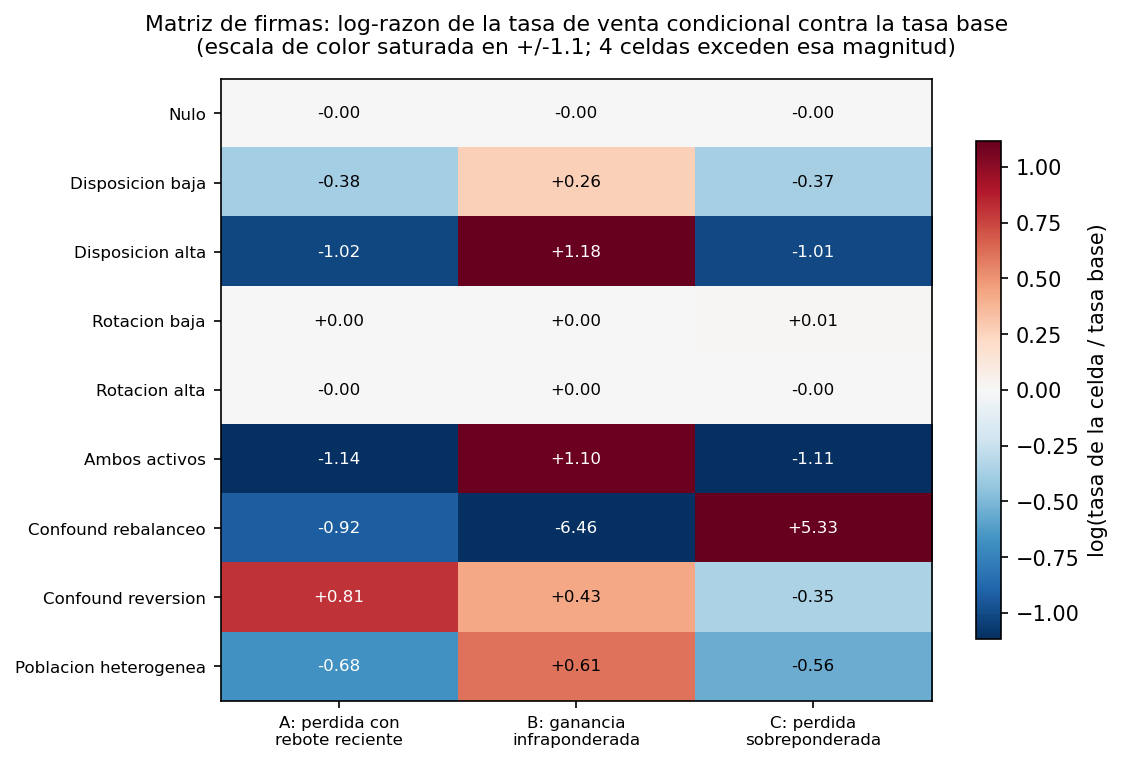

In [28]:
display(Image(str(FIG / "fig08_matriz_firmas.png")))

In [29]:
print(clasif[["escenario", "patron", "mecanismo_por_direccion", "coseno",
              "coseno_segundo", "intensidad_norma"]].round(3).to_string(index=False))
print('''
La clasificacion usa la DIRECCION del vector de tres log-razones (coseno), no su
magnitud: un agente con delta = 0.3 deja la misma firma direccional que uno con
delta = 0.8, solo que mas debil. Cuando la norma es despreciable se dice
'sin mecanismo detectable' en vez de forzar una etiqueta sobre ruido.''')

            escenario                 patron  mecanismo_por_direccion  coseno  coseno_segundo  intensidad_norma
                 Nulo A=base, B=base, C=base sin mecanismo detectable     NaN             NaN             0.001
     Disposicion baja A=baja, B=alta, C=baja              disposicion   0.974          -0.108             0.591
     Disposicion alta A=baja, B=alta, C=baja              disposicion   1.000           0.022             1.856
        Rotacion baja A=base, B=base, C=base sin mecanismo detectable     NaN             NaN             0.015
        Rotacion alta A=base, B=base, C=base sin mecanismo detectable     NaN             NaN             0.005
        Ambos activos A=baja, B=alta, C=baja              disposicion   0.996          -0.030             1.932
  Confound rebalanceo A=baja, B=baja, C=alta               rebalanceo   1.000          -0.653             8.425
   Confound reversion A=alta, B=alta, C=baja                reversion   1.000           0.022           

## 10. Las decisiones contables mueven la medida estándar

Rejilla completa: tres bases de costo x dos convenciones de conteo de ventas
parciales x dos precios de referencia.

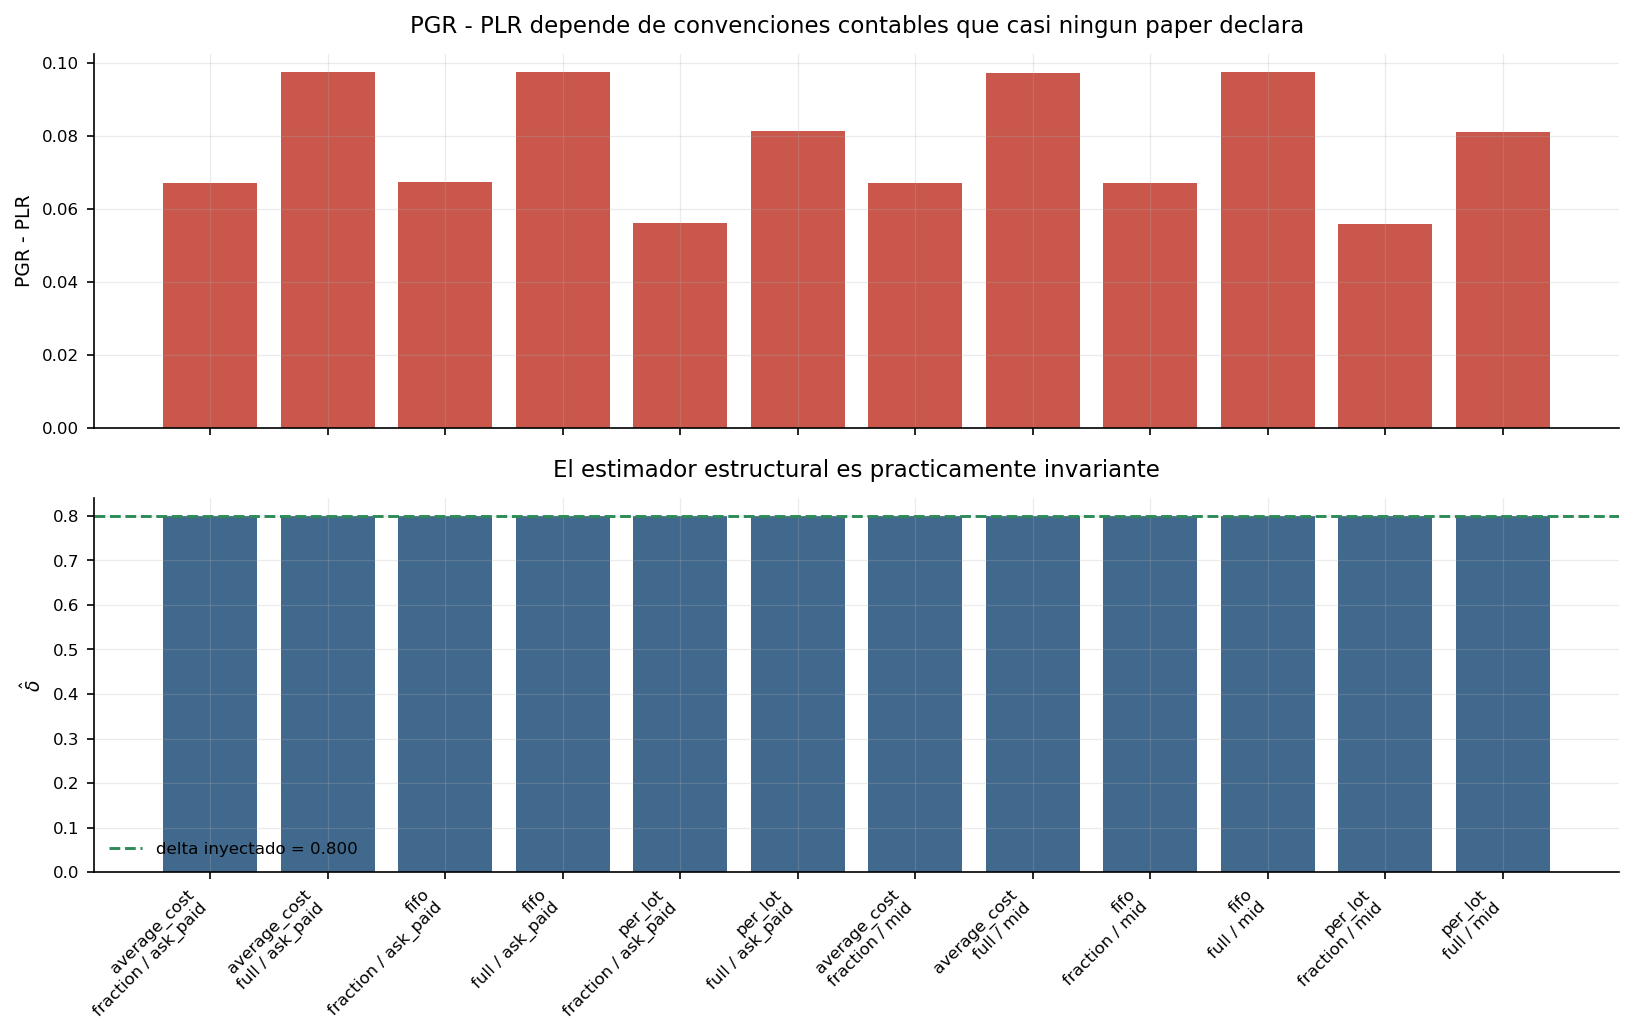

In [30]:
display(Image(str(FIG / "fig10_sensibilidad_contable.png")))

In [31]:
print(rejilla[["base_costo", "conteo_parcial", "referencia", "PGR", "PLR",
               "PGR_menos_PLR", "PGR_sobre_PLR", "delta_hat"]].round(5).to_string(index=False))
r = rejilla["PGR_menos_PLR"]
d = rejilla["delta_hat"]
print(f"\nPGR-PLR: min {r.min():.5f}  max {r.max():.5f}  rango relativo {100 * (r.max() / r.min() - 1):.0f}%")
print(f"delta_hat: min {d.min():.5f}  max {d.max():.5f}  rango relativo {100 * (d.max() / d.min() - 1):.2f}%")
print(f"delta inyectado = {rejilla['delta_inyectado'].iloc[0]:.5f}")

  base_costo      conteo_parcial referencia     PGR     PLR  PGR_menos_PLR  PGR_sobre_PLR  delta_hat
        fifo     partial_as_full        mid 0.11988 0.02250        0.09738        5.32788    0.79935
        fifo partial_as_fraction        mid 0.08254 0.01540        0.06714        5.35948    0.79935
        fifo     partial_as_full   ask_paid 0.12015 0.02256        0.09758        5.32498    0.79929
        fifo partial_as_fraction   ask_paid 0.08273 0.01545        0.06728        5.35542    0.79929
average_cost     partial_as_full        mid 0.11924 0.02212        0.09712        5.39019    0.79935
average_cost partial_as_fraction        mid 0.08210 0.01514        0.06697        5.42450    0.79935
average_cost     partial_as_full   ask_paid 0.11952 0.02219        0.09733        5.38660    0.79936
average_cost partial_as_fraction   ask_paid 0.08233 0.01518        0.06714        5.42223    0.79936
     per_lot     partial_as_full        mid 0.09591 0.01486        0.08106        6.45572  

In [32]:
ef = resultados["efecto_referencia_por_spread"]
print("Efecto de usar 'ask pagado' en vez de 'precio medio' como referencia:")
print(f"  con spread de {ef['spread_bps_base']:.0f} bps : {ef['delta_PGR_menos_PLR_base']:+.5f}")
print(f"  con spread de {ef['spread_bps_ancho']:.0f} bps: {ef['delta_PGR_menos_PLR_ancho']:+.5f}")
print(f"  factor: {ef['delta_PGR_menos_PLR_ancho'] / ef['delta_PGR_menos_PLR_base']:.1f}x")
print('''
El pre-analisis predijo que la referencia 'ask pagado' moveria PGR-PLR de forma
apreciable. Con 10 bps de spread la prediccion FALLA: el sesgo de medio spread
es de 5 bps, despreciable frente a un movimiento diario tipico de ~1.6%. Al
repetir la rejilla con un spread de mercado ilquido (200 bps) el efecto aparece
y escala casi linealmente con el spread. La prediccion era correcta en el
mecanismo y equivocada en la magnitud para activos liquidos.''')

Efecto de usar 'ask pagado' en vez de 'precio medio' como referencia:
  con spread de 10 bps : +0.00023
  con spread de 200 bps: +0.00531
  factor: 23.3x

El pre-analisis predijo que la referencia 'ask pagado' moveria PGR-PLR de forma
apreciable. Con 10 bps de spread la prediccion FALLA: el sesgo de medio spread
es de 5 bps, despreciable frente a un movimiento diario tipico de ~1.6%. Al
repetir la rejilla con un spread de mercado ilquido (200 bps) el efecto aparece
y escala casi linealmente con el spread. La prediccion era correcta en el
mecanismo y equivocada en la magnitud para activos liquidos.


## 11. Integridad del diseño

In [33]:
esc = resultados["escenarios"]
filas = []
for k, v in esc.items():
    i = v["integrity"]
    filas.append({
        "escenario": v["name"],
        "error de conservacion": i["conservation_error_rel"],
        "bruto-neto = costos": i["gross_minus_net_equals_costs"],
        "descomposicion de costos": i["cost_decomposition_error"],
        "dias-unidad neutros": i["neutral_unit_days"],
        "dias-unidad totales": i["total_unit_days"],
        "fusiones de lote": i["merge_events"],
    })
f = pd.DataFrame(filas)
print(f.to_string(index=False))
print(f"\nMaximo error de conservacion en los nueve escenarios: {f['error de conservacion'].max():.2e}")
print(f"Posiciones exactamente al costo: {f['dias-unidad neutros'].sum():.0f} de "
      f"{f['dias-unidad totales'].sum():.0f} dias-unidad (con precios continuos la")
print("igualdad exacta no ocurre nunca; la regla existe y esta probada con un caso")
print("construido a mano en tests/test_portfolio.py).")

            escenario  error de conservacion  bruto-neto = costos  descomposicion de costos  dias-unidad neutros  dias-unidad totales  fusiones de lote
                 Nulo           1.591534e-15         1.791108e-15              2.915913e-17                  0.0            8712948.0            1999.0
     Disposicion baja           1.901728e-15         1.990763e-15              3.142091e-17                  0.0            8905509.0            1953.0
     Disposicion alta           1.364183e-15         1.552586e-15              2.019997e-17                  0.0            9001111.0             975.0
        Rotacion baja           3.488016e-15         3.153599e-15              1.298503e-16                  0.0            8791101.0            2517.0
        Rotacion alta           4.099020e-15         4.328778e-15              2.034830e-16                  0.0            8680304.0            2295.0
        Ambos activos           3.071159e-15         3.042846e-15              1.720973e

In [34]:
print("Lotes abiertos por agente y fusiones (los lotes multiples existen de verdad):")
for k, v in esc.items():
    print(f"  {v['name']:<24} lotes/agente = {v['num_lots_opened_mean']:7.1f}   "
          f"fusiones = {v['integrity']['merge_events']:.0f}")

Lotes abiertos por agente y fusiones (los lotes multiples existen de verdad):
  Nulo                     lotes/agente =   128.0   fusiones = 1999
  Disposicion baja         lotes/agente =   130.8   fusiones = 1953
  Disposicion alta         lotes/agente =    83.7   fusiones = 975
  Rotacion baja            lotes/agente =   237.3   fusiones = 2517
  Rotacion alta            lotes/agente =   390.1   fusiones = 2295
  Ambos activos            lotes/agente =   256.9   fusiones = 3466
  Confound rebalanceo      lotes/agente =    43.8   fusiones = 1289
  Confound reversion       lotes/agente =   152.7   fusiones = 1976
  Poblacion heterogenea    lotes/agente =   247.8   fusiones = 2603


## 12. Resumen

1. **El estimador clásico no recupera el parámetro; el estructural sí.**
   `delta_hat` reproduce `delta` con error absoluto máximo de 0.006 en los siete
   escenarios sin *confound*, mientras que `PGR - PLR` cambia un 53% entre dos
   escenarios con **el mismo** `delta` y distinta propensión a operar.
2. **Los confounds disparan falsos positivos en los dos estimadores.** Con
   `delta = 0` inyectado, el rebalanceo produce `PGR - PLR = +0.012` y
   `delta_hat = +0.16`; la creencia en reversión produce `+0.041` y `+0.38`.
   Ninguno de los dos agentes tiene psicología alguna.
3. **Las celdas discriminantes sí separan los tres mecanismos**, con firmas
   direccionales que no se confunden entre sí (coseno ≥ 0.97 con el mecanismo
   correcto y ≤ 0.02 con el siguiente).